# 15. Fairness, Governance, and Auditability of Explanations

The previous notebook separated model explanations from causal claims. This notebook asks a broader deployment question:

> Are our explanations fair, governable, reproducible, and reviewable?

Interpretability is a modeling technique and a governance practice. In a decision system, explanations become artifacts: they are read by analysts, used by stakeholders, cited in approvals and denials, stored in audit records, and sometimes challenged after a decision. A technically correct explanation can still fail if it is uneven across groups, impossible to reproduce, disconnected from model documentation, or too vague for governance.

## Learning Objectives

By the end of this notebook, you should be able to:

1. Distinguish fairness of model outcomes from fairness of model explanations.
2. Compute subgroup performance metrics such as approval rate, true-positive rate, false-positive rate, and calibration summaries.
3. Audit whether local explanations and denial reasons differ systematically across groups.
4. Measure recourse burden for denied but qualified cases.
5. Build a lightweight audit record with model, data, threshold, metric, and explanation metadata.
6. Translate technical diagnostics into deployment recommendations.

## 1. Why Explanation Governance Is Different From Explanation Quality

An explanation can be faithful to a model and still be problematic in the decision workflow. Three questions must be separated:

| Question | Example | Governance concern |
|---|---|---|
| Is the explanation technically faithful? | Does the explanation reflect the fitted model behavior? | Method validity, stability, reproducibility |
| Is the explanation equitable? | Are explanation quality, denial reasons, or recourse options uneven across groups? | Fairness, access, disparate burden |
| Is the explanation auditable? | Can another reviewer reproduce the explanation from documented data, code, model version, threshold, and policy? | Accountability, documentation, reviewability |

Model cards were proposed to document intended use, performance, limitations, and ethical considerations for deployed models (Mitchell et al., 2019). Datasheets similarly emphasize that data should be documented for downstream users and affected stakeholders (Gebru et al., 2021). The point is not paperwork for its own sake. Documentation makes model behavior inspectable.

## 2. Fairness Metrics We Will Use

Let $A$ denote a sensitive group, $Y$ the true outcome, $\widehat Y$ the decision, and $S$ the model score.

A few useful subgroup metrics are:

$$
\text{ApprovalRate}_a = P(\widehat Y = 1 \mid A=a),
$$

$$
\text{TPR}_a = P(\widehat Y = 1 \mid Y=1, A=a),
$$

$$
\text{FPR}_a = P(\widehat Y = 1 \mid Y=0, A=a).
$$

Hardt, Price, and Srebro (2016) formalize equality of opportunity through true-positive-rate parity. That metric is useful when the main concern is whether qualified individuals receive beneficial decisions at similar rates.

For explanations, we also need explanation-specific diagnostics. If $\phi_j(x)$ is the local contribution of feature $j$ to a prediction, an explanation disparity can be summarized as:

$$
\Delta_j = E[|\phi_j(X)| \mid A=1] - E[|\phi_j(X)| \mid A=0].
$$

This is not a fairness theorem. It is a practical audit question: does one group systematically receive explanations driven by a different set of reasons?

## 3. Decision Case: Working-Capital Approval

We will simulate a working-capital approval system for small businesses.

The model predicts whether a business will repay successfully. A decision rule approves applications above a score threshold. The sensitive group indicator is called `underserved_access_group`. It represents businesses from a historically underserved access channel.

Important design choice: **the model will not use the sensitive group indicator as a feature**. We will use it only for audit reporting. This is deliberate. Removing the group variable from the feature set does not guarantee fairness because other variables can encode historical access differences.

### Governance Roles of the Variables

| Variable | Modeling role | Governance concern |
|---|---|---|
| `revenue`, `cash_buffer` | Financial strength indicators | Actionable but may reflect historical access to capital |
| `credit_history`, `collateral`, `digital_records` | Documentation and credit-access signals | Useful but potentially shaped by unequal historical access |
| `relationship_length`, `business_age` | Relationship and maturity signals | Can favor incumbents over newer entrants |
| `sector_volatility` | Business risk signal | Relevant risk control, but should not dominate recourse messaging |
| `underserved_access_group` | Audit-only sensitive group | Used for fairness evaluation, not model fitting |
| `repays` | Outcome | Target label for model training and fairness metrics |

In [1]:
# Section focus: Governance Roles of the Variables.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')

import hashlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 715
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 130
pd.set_option('display.max_colwidth', 140)


def sigmoid(z):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    z : object
        Linear predictor or standardized score being transformed by this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-z))

In [2]:
# Section focus: Governance Roles of the Variables.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def display_table(df, precision=3, max_width='840px'):
    """Display table for the 15. Fairness, Governance, and Auditability of Explanations notebook output.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    precision : object
        Number of decimal places used when formatting numeric output.
    max_width : object
        Maximum display width used to keep rendered tables readable.
    
    Returns
    -------
    object
        None. The function updates a plot, display object, or notebook state as its side effect.
    """
    styler = df.style.format(precision=precision)
    styler = styler.set_table_styles([
        {'selector': 'th', 'props': [('white-space', 'normal'), ('text-align', 'left'), ('vertical-align', 'top')]},
        {'selector': 'td', 'props': [('white-space', 'normal'), ('text-align', 'left'), ('vertical-align', 'top'), ('line-height', '1.3')]},
        {'selector': 'table', 'props': [('table-layout', 'fixed'), ('width', max_width)]},
    ])
    display(styler)


def safe_divide(numerator, denominator):
    """Carry out the safe divide step used in the 15. Fairness, Governance, and Auditability of Explanations workflow.
    
    Parameters
    ----------
    numerator : object
        The numerator setting that controls the safe divide calculation in this notebook.
    denominator : object
        The denominator setting that controls the safe divide calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the safe divide calculation and reused by later cells.
    """
    return np.nan if denominator == 0 else numerator / denominator

For Governance Roles of the Variables, read the explanation as something a stakeholder may challenge. Stability, clarity, and sensitivity all matter.


In [3]:
# Section focus: Governance Roles of the Variables.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def make_working_capital_data(n=7000, seed=RANDOM_SEED):
    """Construct the working capital data helper used in the 15. Fairness, Governance, and Auditability of Explanations workflow.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)

    underserved_access_group = rng.binomial(1, 0.36, n)
    sector_volatility = rng.normal(0.15 * underserved_access_group, 1, n)
    business_age = rng.normal(-0.25 * underserved_access_group, 1, n)
    true_operating_strength = rng.normal(-0.15 * underserved_access_group, 1, n)

    revenue = (
        0.75 * true_operating_strength
        + 0.35 * business_age
        - 0.30 * sector_volatility
        - 0.35 * underserved_access_group
        + rng.normal(0, 0.75, n)
    )
    cash_buffer = (
        0.65 * true_operating_strength
        - 0.25 * sector_volatility
        - 0.22 * underserved_access_group
        + rng.normal(0, 0.80, n)
    )
    credit_history = (
        0.70 * true_operating_strength
        + 0.25 * business_age
        - 0.65 * underserved_access_group
        + rng.normal(0, 0.85, n)
    )
    digital_records = (
        0.55 * true_operating_strength
        + 0.25 * business_age
        - 0.50 * underserved_access_group
        + rng.normal(0, 0.85, n)
    )
    collateral = (
        0.45 * revenue
        + 0.30 * business_age
        - 0.55 * underserved_access_group
        + rng.normal(0, 0.90, n)
    )
    relationship_length = (
        0.55 * business_age
        + 0.10 * true_operating_strength
        - 0.25 * underserved_access_group
        + rng.normal(0, 0.80, n)
    )

    repayment_logit = (
        -0.10
        + 0.75 * true_operating_strength
        + 0.40 * cash_buffer
        + 0.32 * revenue
        + 0.25 * relationship_length
        - 0.50 * sector_volatility
        + 0.12 * digital_records
    )
    repay_probability = sigmoid(repayment_logit)
    repays = rng.binomial(1, repay_probability)

    return pd.DataFrame({
        'underserved_access_group': underserved_access_group,
        'sector_volatility': sector_volatility,
        'business_age': business_age,
        'true_operating_strength': true_operating_strength,
        'revenue': revenue,
        'cash_buffer': cash_buffer,
        'credit_history': credit_history,
        'digital_records': digital_records,
        'collateral': collateral,
        'relationship_length': relationship_length,
        'repays': repays,
        'repay_probability_true': repay_probability,
    })

applications = make_working_capital_data()
applications.head()

,underserved_access_group,sector_volatility,business_age,true_operating_strength,revenue,cash_buffer,credit_history,digital_records,collateral,relationship_length,repays,repay_probability_true
0,0,0.696477,-0.739939,-0.017705,-0.082105,0.254448,-1.592298,0.426882,0.291908,-0.465655,0,0.389076
1,0,-2.712910,-0.115650,1.493233,2.123318,1.410328,1.806372,1.885788,1.508594,1.137639,1,0.984182
2,1,-0.121850,-1.923736,0.276229,0.217328,0.202704,-2.012017,-1.573604,-0.772319,-1.783448,1,0.421658
3,0,-0.088736,-1.430703,0.645742,0.483881,-0.157146,-1.659604,0.327101,0.094433,-1.334752,1,0.556315
4,0,-0.538425,-1.174020,-0.128180,-2.105026,-0.925511,-0.569584,-0.895477,-1.478070,0.033155,0,0.255421


Governance Roles of the Variables is useful only if the explanation remains credible under reasonable modeling choices.


In [4]:
applications['access_group'] = np.where(
    applications['underserved_access_group'] == 1,
    'Underserved access group',
    'Established access group',
)

population_summary = (
    applications
    .groupby('access_group')
    .agg(
        applications=('repays', 'size'),
        repayment_rate=('repays', 'mean'),
        mean_revenue=('revenue', 'mean'),
        mean_cash_buffer=('cash_buffer', 'mean'),
        mean_credit_history=('credit_history', 'mean'),
        mean_collateral=('collateral', 'mean'),
    )
    .reset_index()
)

display_table(population_summary, precision=3, max_width='820px')

,access_group,applications,repayment_rate,mean_revenue,mean_cash_buffer,mean_credit_history,mean_collateral
0,Established access group,4474,0.474,-0.007,-0.016,0.001,-0.005
1,Underserved access group,2526,0.360,-0.590,-0.368,-0.825,-0.874


The groups differ in observed financial and documentation variables before the model is trained. Those differences require governance to document a documented position on which variables are appropriate for prediction, which are appropriate for recourse messaging, and which require monitoring.

## 4. Train a Transparent Baseline Model

We will fit a logistic regression model. It is not the only possible model, but it gives us a transparent score decomposition. The sensitive group indicator is excluded from the feature set.

In [5]:
# Section focus: 4. Train a Transparent Baseline Model.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

model_features = [
    'revenue',
    'cash_buffer',
    'credit_history',
    'digital_records',
    'collateral',
    'relationship_length',
    'sector_volatility',
    'business_age',
]

audit_features = model_features + ['underserved_access_group', 'access_group']

train_df, test_df = train_test_split(
    applications,
    test_size=0.35,
    random_state=RANDOM_SEED,
    stratify=applications['repays'],
)

approval_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
approval_model.fit(train_df[model_features], train_df['repays'])

test_df = test_df.copy()
test_df['score'] = approval_model.predict_proba(test_df[model_features])[:, 1]

# A fixed capacity rule: approve the top 40% of applicants by score.
threshold = test_df['score'].quantile(0.60)
test_df['approved'] = (test_df['score'] >= threshold).astype(int)

performance = pd.DataFrame({
    'metric': ['ROC AUC', 'Average precision', 'Approval rate', 'Repayment rate', 'Decision threshold'],
    'value': [
        roc_auc_score(test_df['repays'], test_df['score']),
        average_precision_score(test_df['repays'], test_df['score']),
        test_df['approved'].mean(),
        test_df['repays'].mean(),
        threshold,
    ],
})

display_table(performance, precision=3, max_width='560px')

,metric,value
0,ROC AUC,0.834
1,Average precision,0.794
2,Approval rate,0.400
3,Repayment rate,0.433
4,Decision threshold,0.508


This result is an interpretation diagnostic. For Train a Transparent Baseline Model, look at whether the explanation is stable, plausible, and useful for stakeholder review. This is a sign that the explanation is still a working hypothesis.


In [6]:
coef_table = pd.DataFrame({
    'feature': model_features,
    'standardized_logit_coefficient': approval_model.named_steps['logisticregression'].coef_[0],
})
coef_table = coef_table.sort_values('standardized_logit_coefficient', ascending=False)
display_table(coef_table, precision=3, max_width='620px')

,feature,standardized_logit_coefficient
0,revenue,0.649
1,cash_buffer,0.644
5,relationship_length,0.229
2,credit_history,0.205
3,digital_records,0.199
4,collateral,-0.040
7,business_age,-0.121
6,sector_volatility,-0.345


The model has good overall discrimination. Governance starts where the aggregate metric stops. We now ask whether the same decision rule behaves differently across groups.

A caution about the coefficient table: coefficients are **conditional** on the other features in the model. Because variables such as `revenue`, `cash_buffer`, `collateral`, and `business_age` are correlated, a small negative coefficient on `collateral` or `business_age` should not be read as a causal statement or recourse recommendation. It says that, after the stronger correlated signals are already in the model, the remaining incremental association is negative in this fitted score. That is exactly why governance should separate model explanation, causal interpretation, and applicant-facing action advice.

## 5. Subgroup Decision Metrics

The approval decision is beneficial when the applicant would repay. In this setting, the true-positive rate answers:

> Among applicants who would repay, what fraction received approval?

That is an equal-opportunity style diagnostic. We will also report false-positive rate because approving non-repaying applicants creates portfolio risk.

In [7]:
# Section focus: 5. Subgroup Decision Metrics.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def subgroup_metrics(df):
    """Carry out the subgroup metrics step used in the 15. Fairness, Governance, and Auditability of Explanations workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rows = []
    for group_name, group_df in df.groupby('access_group'):
        y = group_df['repays'].to_numpy()
        yhat = group_df['approved'].to_numpy()
        score = group_df['score'].to_numpy()
        rows.append({
            'access_group': group_name,
            'n': len(group_df),
            'repayment_rate': y.mean(),
            'mean_score': score.mean(),
            'approval_rate': yhat.mean(),
            'true_positive_rate': safe_divide(((yhat == 1) & (y == 1)).sum(), (y == 1).sum()),
            'false_positive_rate': safe_divide(((yhat == 1) & (y == 0)).sum(), (y == 0).sum()),
            'precision_among_approved': safe_divide(((yhat == 1) & (y == 1)).sum(), (yhat == 1).sum()),
        })
    return pd.DataFrame(rows)

metrics_by_group = subgroup_metrics(test_df)
display_table(metrics_by_group, precision=3, max_width='920px')

,access_group,n,repayment_rate,mean_score,approval_rate,true_positive_rate,false_positive_rate,precision_among_approved
0,Established access group,1551,0.482,0.493,0.489,0.746,0.250,0.735
1,Underserved access group,899,0.348,0.341,0.246,0.521,0.099,0.738


In Subgroup Decision Metrics, the explanation should help a reviewer understand what is stable, what is fragile, and what still needs checking. The analyst should flag this movement before the explanation supports a decision.


In [8]:
# Section focus: 5. Subgroup Decision Metrics.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def metric_gap(metric_name):
    """Carry out the metric gap step used in the 15. Fairness, Governance, and Auditability of Explanations workflow.
    
    Parameters
    ----------
    metric_name : object
        Name of the evaluation metric being selected or displayed.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the metric gap calculation.
    """
    values = metrics_by_group.set_index('access_group')[metric_name]
    return values['Underserved access group'] - values['Established access group']

gap_table = pd.DataFrame({
    'metric': ['Approval rate gap', 'True-positive-rate gap', 'False-positive-rate gap', 'Mean score gap'],
    'underserved_minus_established': [
        metric_gap('approval_rate'),
        metric_gap('true_positive_rate'),
        metric_gap('false_positive_rate'),
        metric_gap('mean_score'),
    ],
    'audit_reading': [
        'Lower access to approvals if negative.',
        'Lower access among qualified applicants if negative.',
        'Lower risk exposure if negative; must be read with TPR and approval gap.',
        'Score distribution shift; investigate feature and data causes.',
    ],
})

display_table(gap_table, precision=3, max_width='850px')

,metric,underserved_minus_established,audit_reading
0,Approval rate gap,-0.244,Lower access to approvals if negative.
1,True-positive-rate gap,-0.225,Lower access among qualified applicants if negative.
2,False-positive-rate gap,-0.151,Lower risk exposure if negative; must be read with TPR and approval gap.
3,Mean score gap,-0.152,Score distribution shift; investigate feature and data causes.


The explanation result should be compared with the decision story. In Subgroup Decision Metrics, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. The analyst should treat a weak explanation as a signal to revisit the model story.


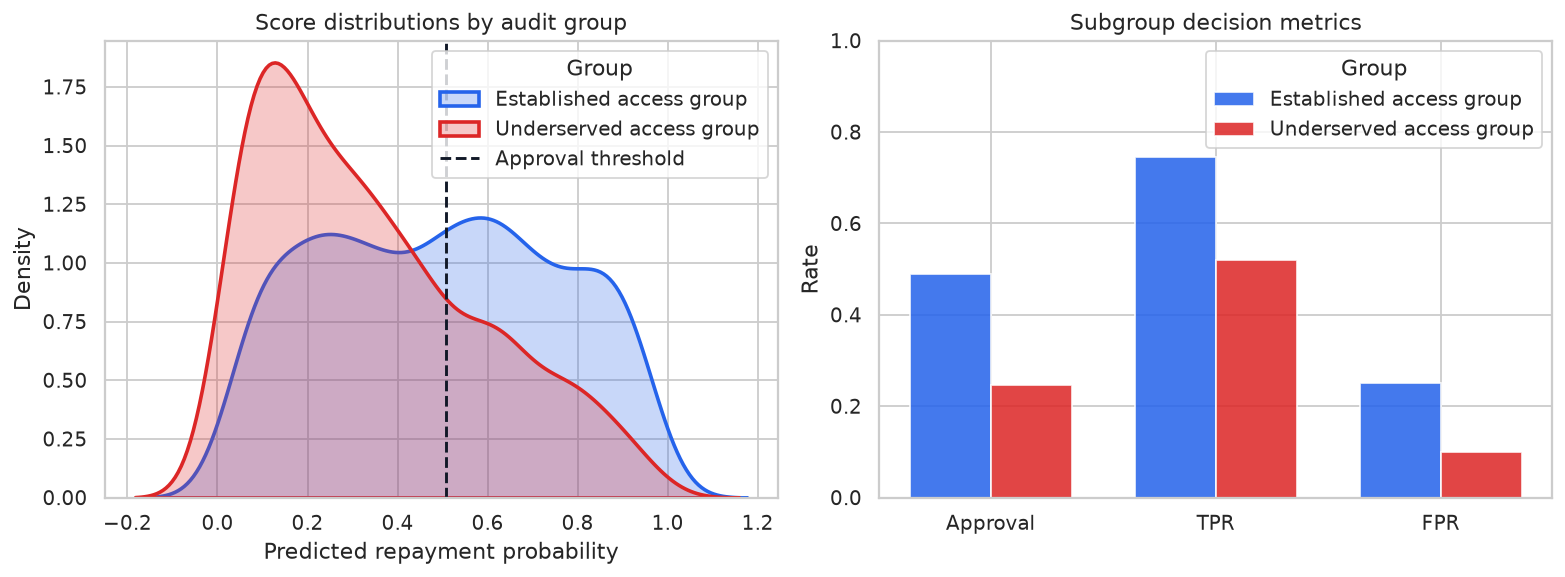

In [9]:
# Section focus: 5. Subgroup Decision Metrics.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.6))

for group_name, color in [
    ('Established access group', '#2563eb'),
    ('Underserved access group', '#dc2626'),
]:
    sns.kdeplot(
        data=test_df.loc[test_df['access_group'] == group_name],
        x='score',
        fill=True,
        alpha=0.25,
        linewidth=2,
        color=color,
        label=group_name,
        ax=axes[0],
    )
axes[0].axvline(threshold, color='#111827', linestyle='--', linewidth=1.6, label='Approval threshold')
axes[0].set_title('Score distributions by audit group')
axes[0].set_xlabel('Predicted repayment probability')
axes[0].set_ylabel('Density')
axes[0].legend(title='Group')

metric_plot = metrics_by_group.set_index('access_group')[['approval_rate', 'true_positive_rate', 'false_positive_rate']]
x = np.arange(metric_plot.shape[1])
width = 0.36
colors = ['#2563eb', '#dc2626']
for offset, (group_name, color) in zip([-width / 2, width / 2], zip(metric_plot.index, colors)):
    axes[1].bar(x + offset, metric_plot.loc[group_name], width=width, label=group_name, color=color, alpha=0.86)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Approval', 'TPR', 'FPR'])
axes[1].set_ylim(0, 1)
axes[1].set_title('Subgroup decision metrics')
axes[1].set_ylabel('Rate')
axes[1].legend(title='Group')

plt.tight_layout()
plt.show()

The model does not use the group indicator, but the decision rule still has a lower approval rate and lower true-positive rate for the underserved access group. That is the governance lesson: fairness auditing requires subgroup measurement even when the protected or sensitive attribute is excluded from the model.

## 6. Explanation Audit: Are Reasons Distributed Differently?

For a standardized logistic model, the logit score can be decomposed as:

$$
\operatorname{logit}(S_i) = \beta_0 + \sum_j \beta_j z_{ij},
$$

where $z_{ij}$ is the standardized value of feature $j$ for applicant $i$. The local contribution of feature $j$ is:

$$
\phi_{ij} = \beta_j z_{ij}.
$$

This is a simple explanation method. It is not SHAP, but it is faithful to this linear model. We will audit whether the magnitude of these contributions differs by group.

In [10]:
# Section focus: 6. Explanation Audit: Are Reasons Distributed Differently?.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

scaler = approval_model.named_steps['standardscaler']
logit_model = approval_model.named_steps['logisticregression']

standardized_test = (test_df[model_features] - scaler.mean_) / scaler.scale_
contributions = standardized_test * logit_model.coef_[0]
contributions.columns = model_features
logit_score = logit_model.intercept_[0] + contributions.sum(axis=1)

contribution_audit = []
for group_name, idx in test_df.groupby('access_group').groups.items():
    group_contrib = contributions.loc[idx]
    for feature in model_features:
        contribution_audit.append({
            'access_group': group_name,
            'feature': feature,
            'mean_abs_contribution': group_contrib[feature].abs().mean(),
            'mean_signed_contribution': group_contrib[feature].mean(),
        })

contribution_audit = pd.DataFrame(contribution_audit)
contribution_gap = (
    contribution_audit
    .pivot(index='feature', columns='access_group', values='mean_abs_contribution')
    .assign(
        abs_contribution_gap=lambda d: d['Underserved access group'] - d['Established access group'],
        max_group_mean=lambda d: d[['Established access group', 'Underserved access group']].max(axis=1),
        relative_gap_share=lambda d: (
            (d['Underserved access group'] - d['Established access group']).abs()
            / d[['Established access group', 'Underserved access group']].max(axis=1)
        ),
    )
    .sort_values('abs_contribution_gap', ascending=False)
    .reset_index()
)

display_table(contribution_gap, precision=3, max_width='850px')

access_group,feature,Established access group,Underserved access group,abs_contribution_gap,max_group_mean,relative_gap_share
0,credit_history,0.160,0.176,0.017,0.176,0.094
1,revenue,0.511,0.524,0.013,0.524,0.025
2,digital_records,0.160,0.163,0.003,0.163,0.019
3,sector_volatility,0.285,0.288,0.003,0.288,0.011
4,collateral,0.031,0.034,0.003,0.034,0.081
5,relationship_length,0.184,0.185,0.000,0.185,0.002
6,business_age,0.096,0.096,-0.000,0.096,0.004
7,cash_buffer,0.511,0.503,-0.008,0.511,0.015


The explanation result should be compared with the decision story. In Explanation Audit: Are Reasons Distributed Differently?, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. The goal is to reduce ambiguity without hiding uncertainty.


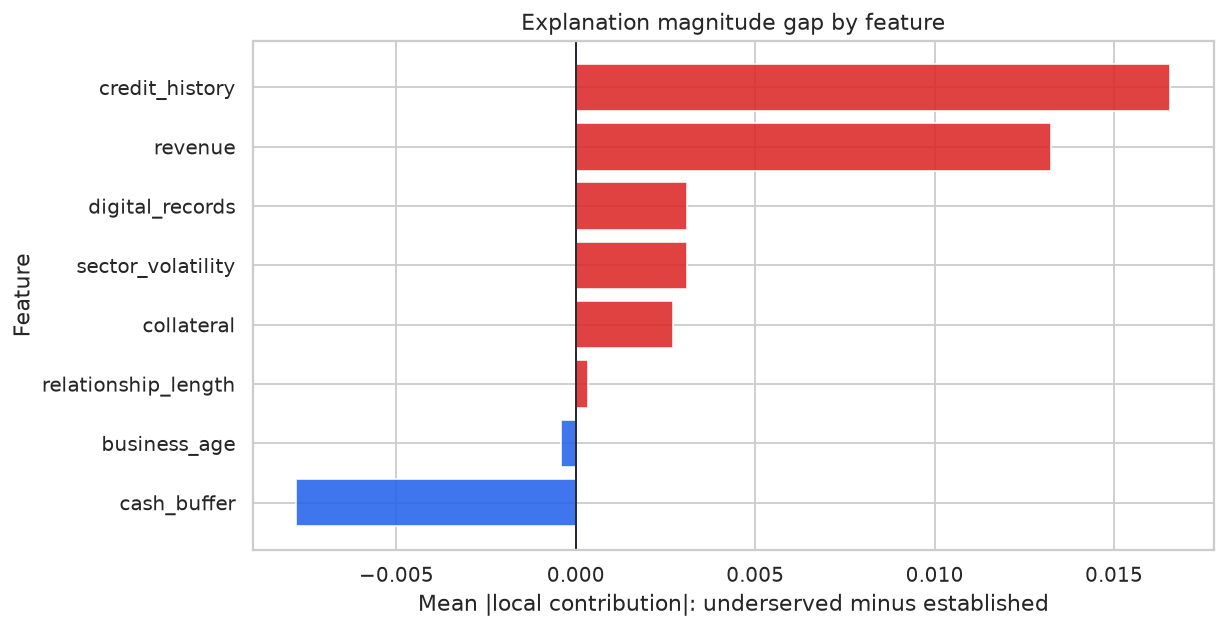

In [11]:
plot_gap = contribution_gap.sort_values('abs_contribution_gap')
fig, ax = plt.subplots(figsize=(9.6, 5.0))
colors = np.where(plot_gap['abs_contribution_gap'] >= 0, '#dc2626', '#2563eb')
ax.barh(plot_gap['feature'], plot_gap['abs_contribution_gap'], color=colors, alpha=0.88)
ax.axvline(0, color='#111827', linewidth=1)
ax.set_title('Explanation magnitude gap by feature')
ax.set_xlabel('Mean |local contribution|: underserved minus established')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

An explanation audit identifies where governance attention is needed before deciding whether any feature should be removed. A larger contribution from credit-history or documentation features for one group may require a policy review: is the feature measuring repayment ability, historical access to documentation, or both?

The `relative_gap_share` column scales the absolute gap by the larger group mean for that feature. That makes the audit table easier to read: a small raw logit gap can still indicate that a feature is proportionally more central to one group's explanation profile.

## 7. Denial Reasons by Group

For denied applicants, we can identify the largest negative contribution in the linear score. This approximates the main reason the model score fell below the threshold.

This is not enough for a final customer-facing explanation. But it is useful as an internal audit diagnostic: if denial reasons differ strongly by group, stakeholders should inspect whether the reasons are valid, actionable, and consistently communicated.

In [12]:
# Section focus: 7. Denial Reasons by Group.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

denied = test_df.loc[test_df['approved'] == 0].copy()
denied_contrib = contributions.loc[denied.index]
denied['top_negative_reason'] = denied_contrib.idxmin(axis=1)

reason_share = (
    denied
    .groupby(['access_group', 'top_negative_reason'])
    .size()
    .rename('count')
    .reset_index()
)
reason_share['share'] = reason_share['count'] / reason_share.groupby('access_group')['count'].transform('sum')

reason_pivot = (
    reason_share
    .pivot(index='top_negative_reason', columns='access_group', values='share')
    .fillna(0)
    .assign(
        reason_gap=lambda d: d['Underserved access group'] - d['Established access group']
    )
    .sort_values('Underserved access group', ascending=False)
    .reset_index()
)

display_table(reason_pivot, precision=3, max_width='820px')

access_group,top_negative_reason,Established access group,Underserved access group,reason_gap
0,revenue,0.337,0.375,0.038
1,cash_buffer,0.390,0.342,-0.048
2,sector_volatility,0.162,0.118,-0.044
3,relationship_length,0.054,0.068,0.014
4,credit_history,0.016,0.052,0.035
5,digital_records,0.029,0.038,0.009
6,business_age,0.010,0.007,-0.003
7,collateral,0.001,0.000,-0.001


In Denial Reasons by Group, the explanation should make substantive and visual sense together. When the reasons move across views, the report should say where the story is fragile.


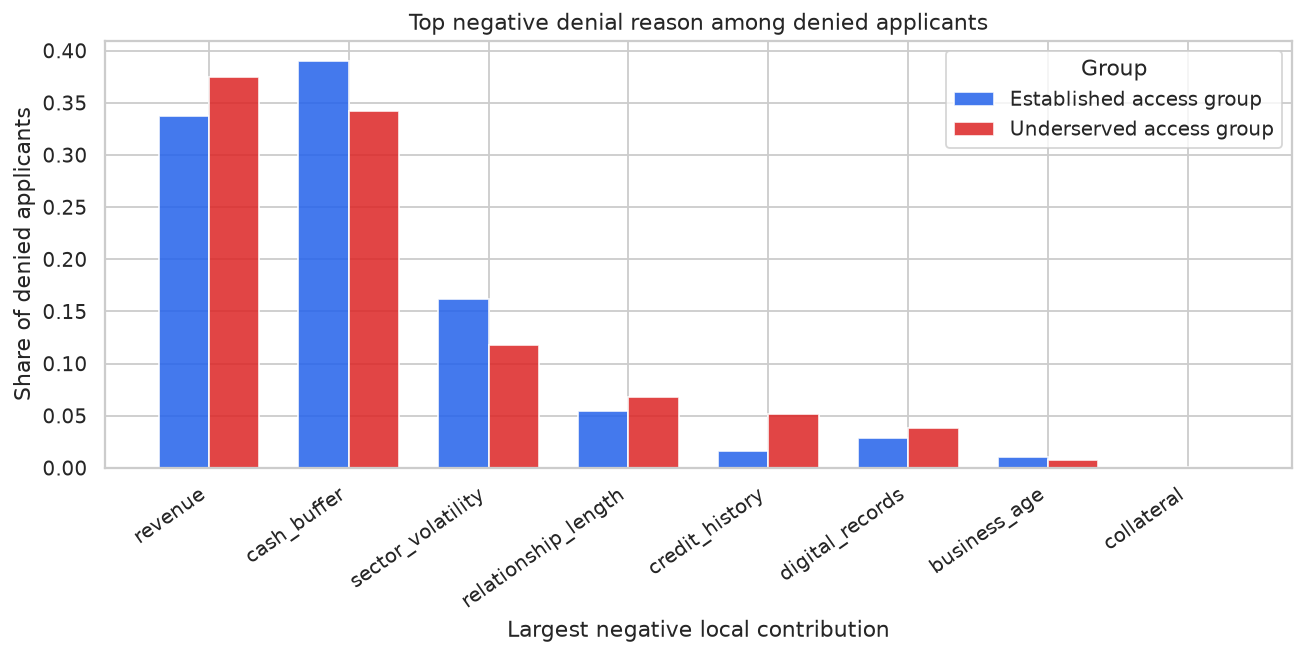

In [13]:
reason_order = reason_pivot['top_negative_reason'].tolist()
fig, ax = plt.subplots(figsize=(10.2, 5.2))
x = np.arange(len(reason_order))
width = 0.36
for offset, group_name, color in [
    (-width / 2, 'Established access group', '#2563eb'),
    (width / 2, 'Underserved access group', '#dc2626'),
]:
    values = reason_pivot.set_index('top_negative_reason').loc[reason_order, group_name]
    ax.bar(x + offset, values, width=width, label=group_name, color=color, alpha=0.86)
ax.set_xticks(x)
ax.set_xticklabels(reason_order, rotation=35, ha='right')
ax.set_title('Top negative denial reason among denied applicants')
ax.set_ylabel('Share of denied applicants')
ax.set_xlabel('Largest negative local contribution')
ax.legend(title='Group')
plt.tight_layout()
plt.show()

If the denial-reason mix differs across groups, the governance response should ask whether each reason is valid, whether the applicant can act on it, whether the same standard is applied consistently, and whether the feature itself needs additional review.

## 8. Recourse Burden

Explanations become much more consequential when they imply recourse: what can a denied applicant do differently?

For a linear logit score, the standardized distance to the approval threshold is:

$$
\tau - \left(\beta_0 + \sum_j \beta_j z_{ij}\right),
$$

where $\tau$ is the logit threshold. If the applicant is below threshold, a rough minimum standardized burden over actionable positive features is:

$$
\text{Burden}_i = \frac{\max\{0, \tau - \operatorname{logit}(S_i)\}}{\|\beta_{\mathcal A}^{+}\|_2},
$$

where $\mathcal A$ is the actionable feature set and $\beta_{\mathcal A}^{+}$ keeps only positive coefficients. This is a simplified diagnostic, but it gives a useful fairness signal: are qualified but denied applicants in one group farther from feasible approval?

In [14]:
# Section focus: 8. Recourse Burden.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

actionable_features = ['revenue', 'cash_buffer', 'credit_history', 'digital_records', 'relationship_length']
coefs = pd.Series(logit_model.coef_[0], index=model_features)
positive_actionable_coefs = coefs[actionable_features].clip(lower=0)
actionable_norm = np.linalg.norm(positive_actionable_coefs.values)
logit_threshold = np.log(threshold / (1 - threshold))

test_df['logit_score'] = logit_score
test_df['recourse_burden'] = np.maximum(0, logit_threshold - test_df['logit_score']) / actionable_norm

qualified_denied = test_df.loc[(test_df['approved'] == 0) & (test_df['repays'] == 1)].copy()

burden_summary = (
    qualified_denied
    .groupby('access_group')
    .agg(
        qualified_denied_cases=('recourse_burden', 'size'),
        mean_burden=('recourse_burden', 'mean'),
        median_burden=('recourse_burden', 'median'),
        p75_burden=('recourse_burden', lambda s: s.quantile(0.75)),
        max_burden=('recourse_burden', 'max'),
    )
    .reset_index()
)

display_table(burden_summary, precision=3, max_width='780px')

,access_group,qualified_denied_cases,mean_burden,median_burden,p75_burden,max_burden
0,Established access group,190,0.717,0.550,1.021,3.226
1,Underserved access group,150,0.900,0.803,1.228,3.241


The explanation result should be compared with the decision story. In Recourse Burden, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. Explanation quality matters in practice because it shapes communication, review burden, and the defensibility of the recommendation.


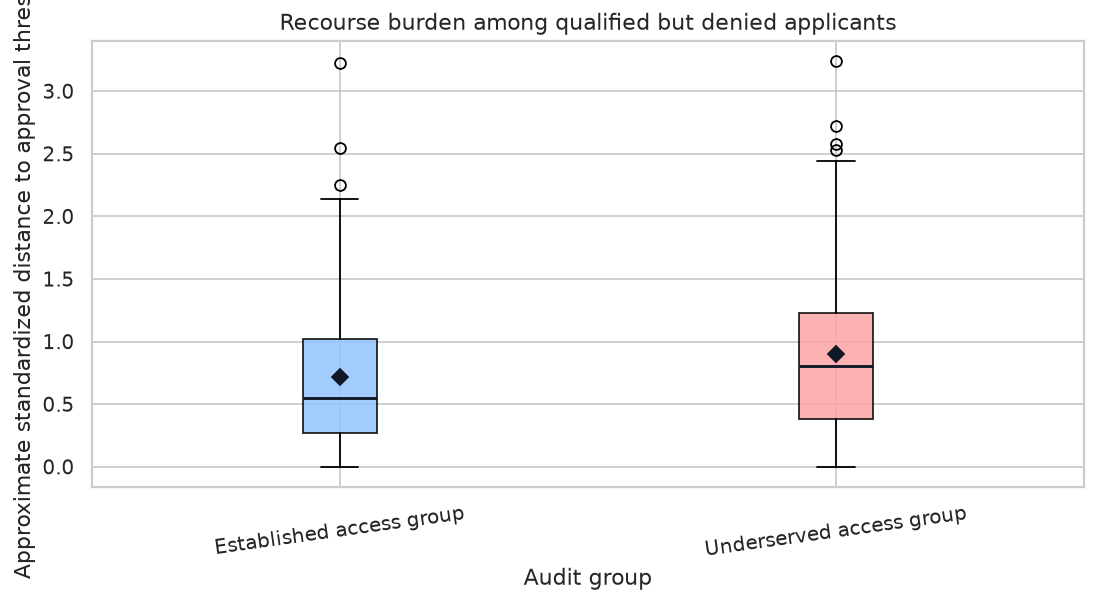

In [15]:
fig, ax = plt.subplots(figsize=(8.6, 4.8))
group_order = ['Established access group', 'Underserved access group']
box_data = [qualified_denied.loc[qualified_denied['access_group'] == group, 'recourse_burden'] for group in group_order]
box = ax.boxplot(box_data, patch_artist=True, showmeans=True)
ax.set_xticks([1, 2])
ax.set_xticklabels(group_order)
for patch, color in zip(box['boxes'], ['#93c5fd', '#fca5a5']):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
for median in box['medians']:
    median.set_color('#111827')
    median.set_linewidth(1.6)
for mean in box['means']:
    mean.set_marker('D')
    mean.set_markerfacecolor('#111827')
    mean.set_markeredgecolor('#111827')
ax.set_title('Recourse burden among qualified but denied applicants')
ax.set_ylabel('Approximate standardized distance to approval threshold')
ax.set_xlabel('Audit group')
ax.tick_params(axis='x', rotation=8)
plt.tight_layout()
plt.show()

The boxplot focuses on applicants who repaid in the simulated outcome but were denied by the model. If one group has higher recourse burden, explanation governance should ask whether the suggested improvement path is realistically available to that group. A recourse statement such as "increase collateral" may be formally actionable but practically inequitable.

## 9. Audit Triggers

A governance workflow needs thresholds for escalation. These thresholds are policy choices, not universal truths. Here we use illustrative triggers:

| Trigger | Example threshold | Why it matters |
|---|---:|---|
| Approval-rate gap | More than 5 percentage points | Detects access differences in the decision rule |
| True-positive-rate gap | More than 5 percentage points | Detects unequal access among qualified applicants |
| Explanation contribution gap | More than 5 logit-contribution points | Detects group differences in explanation drivers |
| Median recourse-burden ratio | More than 1.10 | Detects uneven difficulty of reaching approval |

In [16]:
median_burden = burden_summary.set_index('access_group')['median_burden']
burden_ratio = median_burden['Underserved access group'] / median_burden['Established access group']
max_explanation_gap = contribution_gap['abs_contribution_gap'].abs().max()

audit_trigger_table = pd.DataFrame({
    'audit_check': [
        'Approval-rate gap',
        'True-positive-rate gap',
        'Largest explanation contribution gap',
        'Median recourse-burden ratio',
    ],
    'observed_value': [
        abs(metric_gap('approval_rate')),
        abs(metric_gap('true_positive_rate')),
        max_explanation_gap,
        burden_ratio,
    ],
    'trigger_threshold': [0.05, 0.05, 0.05, 1.10],
})
audit_trigger_table['requires_review'] = audit_trigger_table['observed_value'] > audit_trigger_table['trigger_threshold']

display_table(audit_trigger_table, precision=3, max_width='760px')

,audit_check,observed_value,trigger_threshold,requires_review
0,Approval-rate gap,0.244,0.050,True
1,True-positive-rate gap,0.225,0.050,True
2,Largest explanation contribution gap,0.017,0.050,False
3,Median recourse-burden ratio,1.461,1.100,True


A triggered audit calls for documented review before deployment: root-cause analysis, stakeholder interpretation, possible threshold changes, feature policy review, and monitoring after launch.

The explanation result should be compared with the decision story. In Audit Triggers, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. A weak explanation creates extra review work and makes the recommendation harder to defend.


## 10. Audit Trail and Model Card Fragment

Auditability means a future reviewer can reconstruct what was evaluated. At minimum, the record should include:

| Artifact | What to record |
|---|---|
| Data snapshot | Dataset version, inclusion criteria, label definition, sensitive attributes used for audit |
| Model snapshot | Model family, feature list, random seed, preprocessing, hyperparameters |
| Decision policy | Threshold rule, capacity constraints, override policy |
| Explanation method | Method name, input features, scope, limitations, stability checks |
| Fairness dashboard | Subgroup performance, explanation disparities, recourse burden |
| Governance decision | Approved, blocked, or conditional launch with monitoring requirements |

In [17]:
# Section focus: 10. Audit Trail and Model Card Fragment.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def short_hash(obj):
    """Carry out the short hash step used in the 15. Fairness, Governance, and Auditability of Explanations workflow.
    
    Parameters
    ----------
    obj : object
        The obj setting that controls the short hash calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the short hash calculation and reused by later cells.
    """
    payload = json.dumps(obj, sort_keys=True, default=str).encode('utf-8')
    return hashlib.sha256(payload).hexdigest()[:12]

feature_hash = short_hash(model_features)
data_signature = short_hash(
    applications[['underserved_access_group', 'revenue', 'cash_buffer', 'credit_history', 'repays']]
    .head(200)
    .round(6)
    .to_dict(orient='records')
)
metric_signature = short_hash(
    metrics_by_group.round(6).to_dict(orient='records')
)

audit_record = pd.DataFrame({
    'field': [
        'model_family',
        'model_version',
        'feature_set_hash',
        'data_snapshot_signature',
        'metric_snapshot_signature',
        'random_seed',
        'training_rows',
        'evaluation_rows',
        'threshold_policy',
        'sensitive_attribute_use',
        'explanation_method',
        'governance_status',
    ],
    'value': [
        'standardized logistic regression',
        'working-capital-baseline-v1',
        feature_hash,
        data_signature,
        metric_signature,
        RANDOM_SEED,
        len(train_df),
        len(test_df),
        'approve top 40 percent by predicted repayment score',
        'excluded from model fitting; used for subgroup audit only',
        'standardized logit contribution plus denial-reason and recourse-burden audit',
        'conditional review required before deployment',
    ],
})

display_table(audit_record, precision=3, max_width='860px')

,field,value
0,model_family,standardized logistic regression
1,model_version,working-capital-baseline-v1
2,feature_set_hash,c314935cea9d
3,data_snapshot_signature,6f512144caf5
4,metric_snapshot_signature,523d979a47c0
5,random_seed,715
6,training_rows,4550
7,evaluation_rows,2450
8,threshold_policy,approve top 40 percent by predicted repayment score
9,sensitive_attribute_use,excluded from model fitting; used for subgroup audit only


This result is an interpretation diagnostic. For Audit Trail and Model Card Fragment, look at whether the explanation is stable, plausible, and useful for stakeholder review. A stable explanation can support action; a moving one should stay in review.


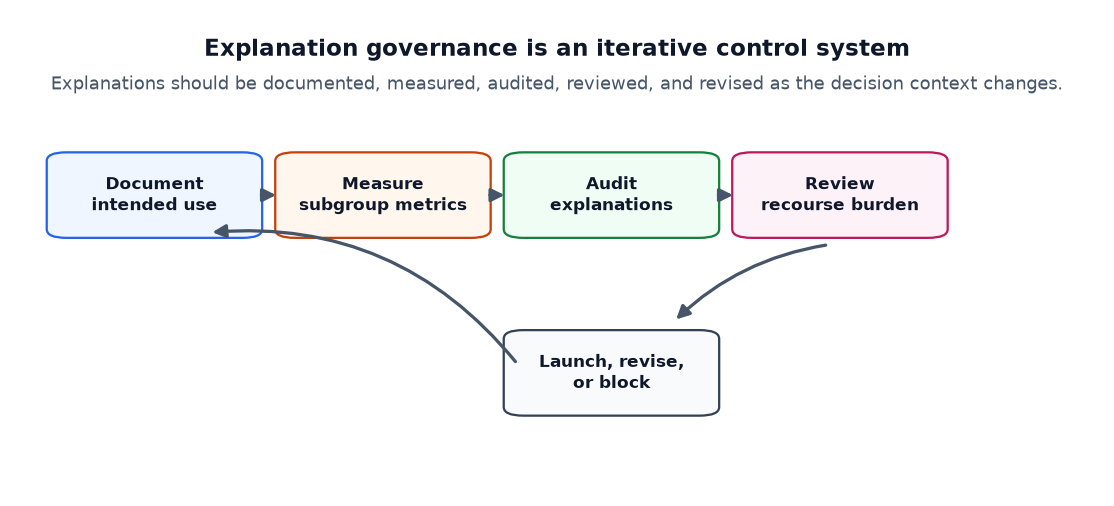

In [18]:
# Section focus: 10. Audit Trail and Model Card Fragment.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def draw_governance_loop():
    """Carry out the draw governance loop step used in the 15. Fairness, Governance, and Auditability of Explanations workflow.
    
    Parameters
    ----------
    None
        This helper uses values defined in the surrounding notebook cell.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    fig, ax = plt.subplots(figsize=(10.8, 4.8))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    boxes = [
        ('Document\nintended use', 0.13, 0.62, '#eff6ff', '#2563eb'),
        ('Measure\nsubgroup metrics', 0.34, 0.62, '#fff7ed', '#c2410c'),
        ('Audit\nexplanations', 0.55, 0.62, '#f0fdf4', '#15803d'),
        ('Review\nrecourse burden', 0.76, 0.62, '#fdf2f8', '#be185d'),
        ('Launch, revise,\nor block', 0.55, 0.25, '#f8fafc', '#334155'),
    ]

    def add_box(label, x, y, face, edge):
        """Carry out the add box step used in the 15. Fairness, Governance, and Auditability of Explanations workflow.
        
        Parameters
        ----------
        label : object
            Human-readable label used to name a model, scenario, metric, or plotted series.
        x : object
            Numeric score, scalar, or array passed through the transformation in this helper.
        y : object
            Observed target values used for fitting or evaluation.
        face : object
            Face color used to encode a node or region in a graph or plot.
        edge : object
            Graph edge being drawn, classified, or checked for consistency.
        
        Returns
        -------
        object
            None. The function updates a plot, display object, or notebook state as its side effect.
        """
        patch = FancyBboxPatch(
            (x - 0.085, y - 0.075),
            0.17,
            0.15,
            boxstyle='round,pad=0.014,rounding_size=0.018',
            facecolor=face,
            edgecolor=edge,
            linewidth=1.25,
        )
        ax.add_patch(patch)
        ax.text(x, y, label, ha='center', va='center', fontsize=9.7, weight='bold', color='#0f172a')

    def add_arrow(start, end, rad=0.0):
        """Carry out the add arrow step used in the 15. Fairness, Governance, and Auditability of Explanations workflow.
        
        Parameters
        ----------
        start : object
            Starting index, time, or location for the simulated event window.
        end : object
            Ending index, time, or location for the simulated event window.
        rad : object
            Curvature setting used to route a graph edge around other visual elements.
        
        Returns
        -------
        object
            None. The function updates a plot, display object, or notebook state as its side effect.
        """
        ax.add_patch(FancyArrowPatch(
            start,
            end,
            connectionstyle=f'arc3,rad={rad}',
            arrowstyle='-|>',
            mutation_scale=15,
            linewidth=1.8,
            color='#475569',
            shrinkA=8,
            shrinkB=8,
        ))

    for label, x, y, face, edge in boxes:
        add_box(label, x, y, face, edge)

    add_arrow((0.215, 0.62), (0.255, 0.62))
    add_arrow((0.425, 0.62), (0.465, 0.62))
    add_arrow((0.635, 0.62), (0.675, 0.62))
    add_arrow((0.76, 0.52), (0.60, 0.34), rad=0.18)
    add_arrow((0.47, 0.25), (0.17, 0.54), rad=0.28)

    ax.text(0.5, 0.91, 'Explanation governance is an iterative control system', ha='center', fontsize=13, weight='bold', color='#0f172a')
    ax.text(0.5, 0.84, 'Explanations should be documented, measured, audited, reviewed, and revised as the decision context changes.', ha='center', fontsize=10, color='#475569')
    return fig, ax

draw_governance_loop();
plt.show()

This result is an interpretation diagnostic. For Audit Trail and Model Card Fragment, look at whether the explanation is stable, plausible, and useful for stakeholder review. The useful version of a fragile story is one that clearly states its boundaries.


## 11. Deployment Recommendation for This Case

Based on the diagnostics above, the correct recommendation is not "the model is unfair" or "the model is fine." The evidence supports a more professional decision:

| Decision question | Finding | Recommended action |
|---|---|---|
| Does the model perform well overall? | Yes, aggregate discrimination is strong. | Keep as a candidate model. |
| Are subgroup decision rates similar? | No, approval and true-positive rates differ. | Trigger fairness review before launch. |
| Are explanations similar across groups? | Some reason and contribution gaps appear. | Review feature policy and denial-message templates. |
| Is recourse burden similar? | Qualified denied applicants in the underserved group face higher burden. | Avoid generic recourse language; test realistic action paths. |
| Is the system auditable? | A basic audit record can be produced. | Promote to formal model-card and monitoring workflow. |

A reasonable governance decision is **conditional deployment only after policy review**, with monitoring of subgroup metrics, denial reasons, and recourse burden.

## 12. Key Takeaways

- Explanation quality is not the same as explanation governance.
- Excluding a sensitive attribute from a model does not remove the need for subgroup auditing.
- Fairness metrics evaluate decisions; explanation metrics evaluate the reasons communicated around those decisions.
- Recourse should be audited for feasibility, burden, and mathematical availability.
- Documentation artifacts such as model cards and datasheets help make model behavior reproducible and reviewable.
- Fairness is sociotechnical: technical metrics should inform governance, but they do not replace stakeholder, legal, ethical, and domain review.

## References

Dwork, C., Hardt, M., Pitassi, T., Reingold, O., & Zemel, R. (2012). Fairness through awareness. *Proceedings of the 3rd Innovations in Theoretical Computer Science Conference*, 214-226. [https://doi.org/10.1145/2090236.2090255](https://doi.org/10.1145/2090236.2090255)

Gebru, T., Morgenstern, J., Vecchione, B., Vaughan, J. W., Wallach, H., Daume III, H., & Crawford, K. (2021). Datasheets for datasets. *Communications of the ACM, 64*(12), 86-92. [https://doi.org/10.1145/3458723](https://doi.org/10.1145/3458723)

Hardt, M., Price, E., & Srebro, N. (2016). Equality of opportunity in supervised learning. *arXiv*. [https://doi.org/10.48550/arxiv.1610.02413](https://doi.org/10.48550/arxiv.1610.02413)

Mitchell, M., Wu, S., Zaldivar, A., Barnes, P., Vasserman, L., Hutchinson, B., Spitzer, E., Raji, I. D., & Gebru, T. (2019). Model cards for model reporting. *Proceedings of the Conference on Fairness, Accountability, and Transparency*, 220-229. [https://doi.org/10.1145/3287560.3287596](https://doi.org/10.1145/3287560.3287596)

Selbst, A. D., boyd, d., Friedler, S. A., Venkatasubramanian, S., & Vertesi, J. (2019). Fairness and abstraction in sociotechnical systems. *Proceedings of the Conference on Fairness, Accountability, and Transparency*, 59-68. [https://doi.org/10.1145/3287560.3287598](https://doi.org/10.1145/3287560.3287598)
